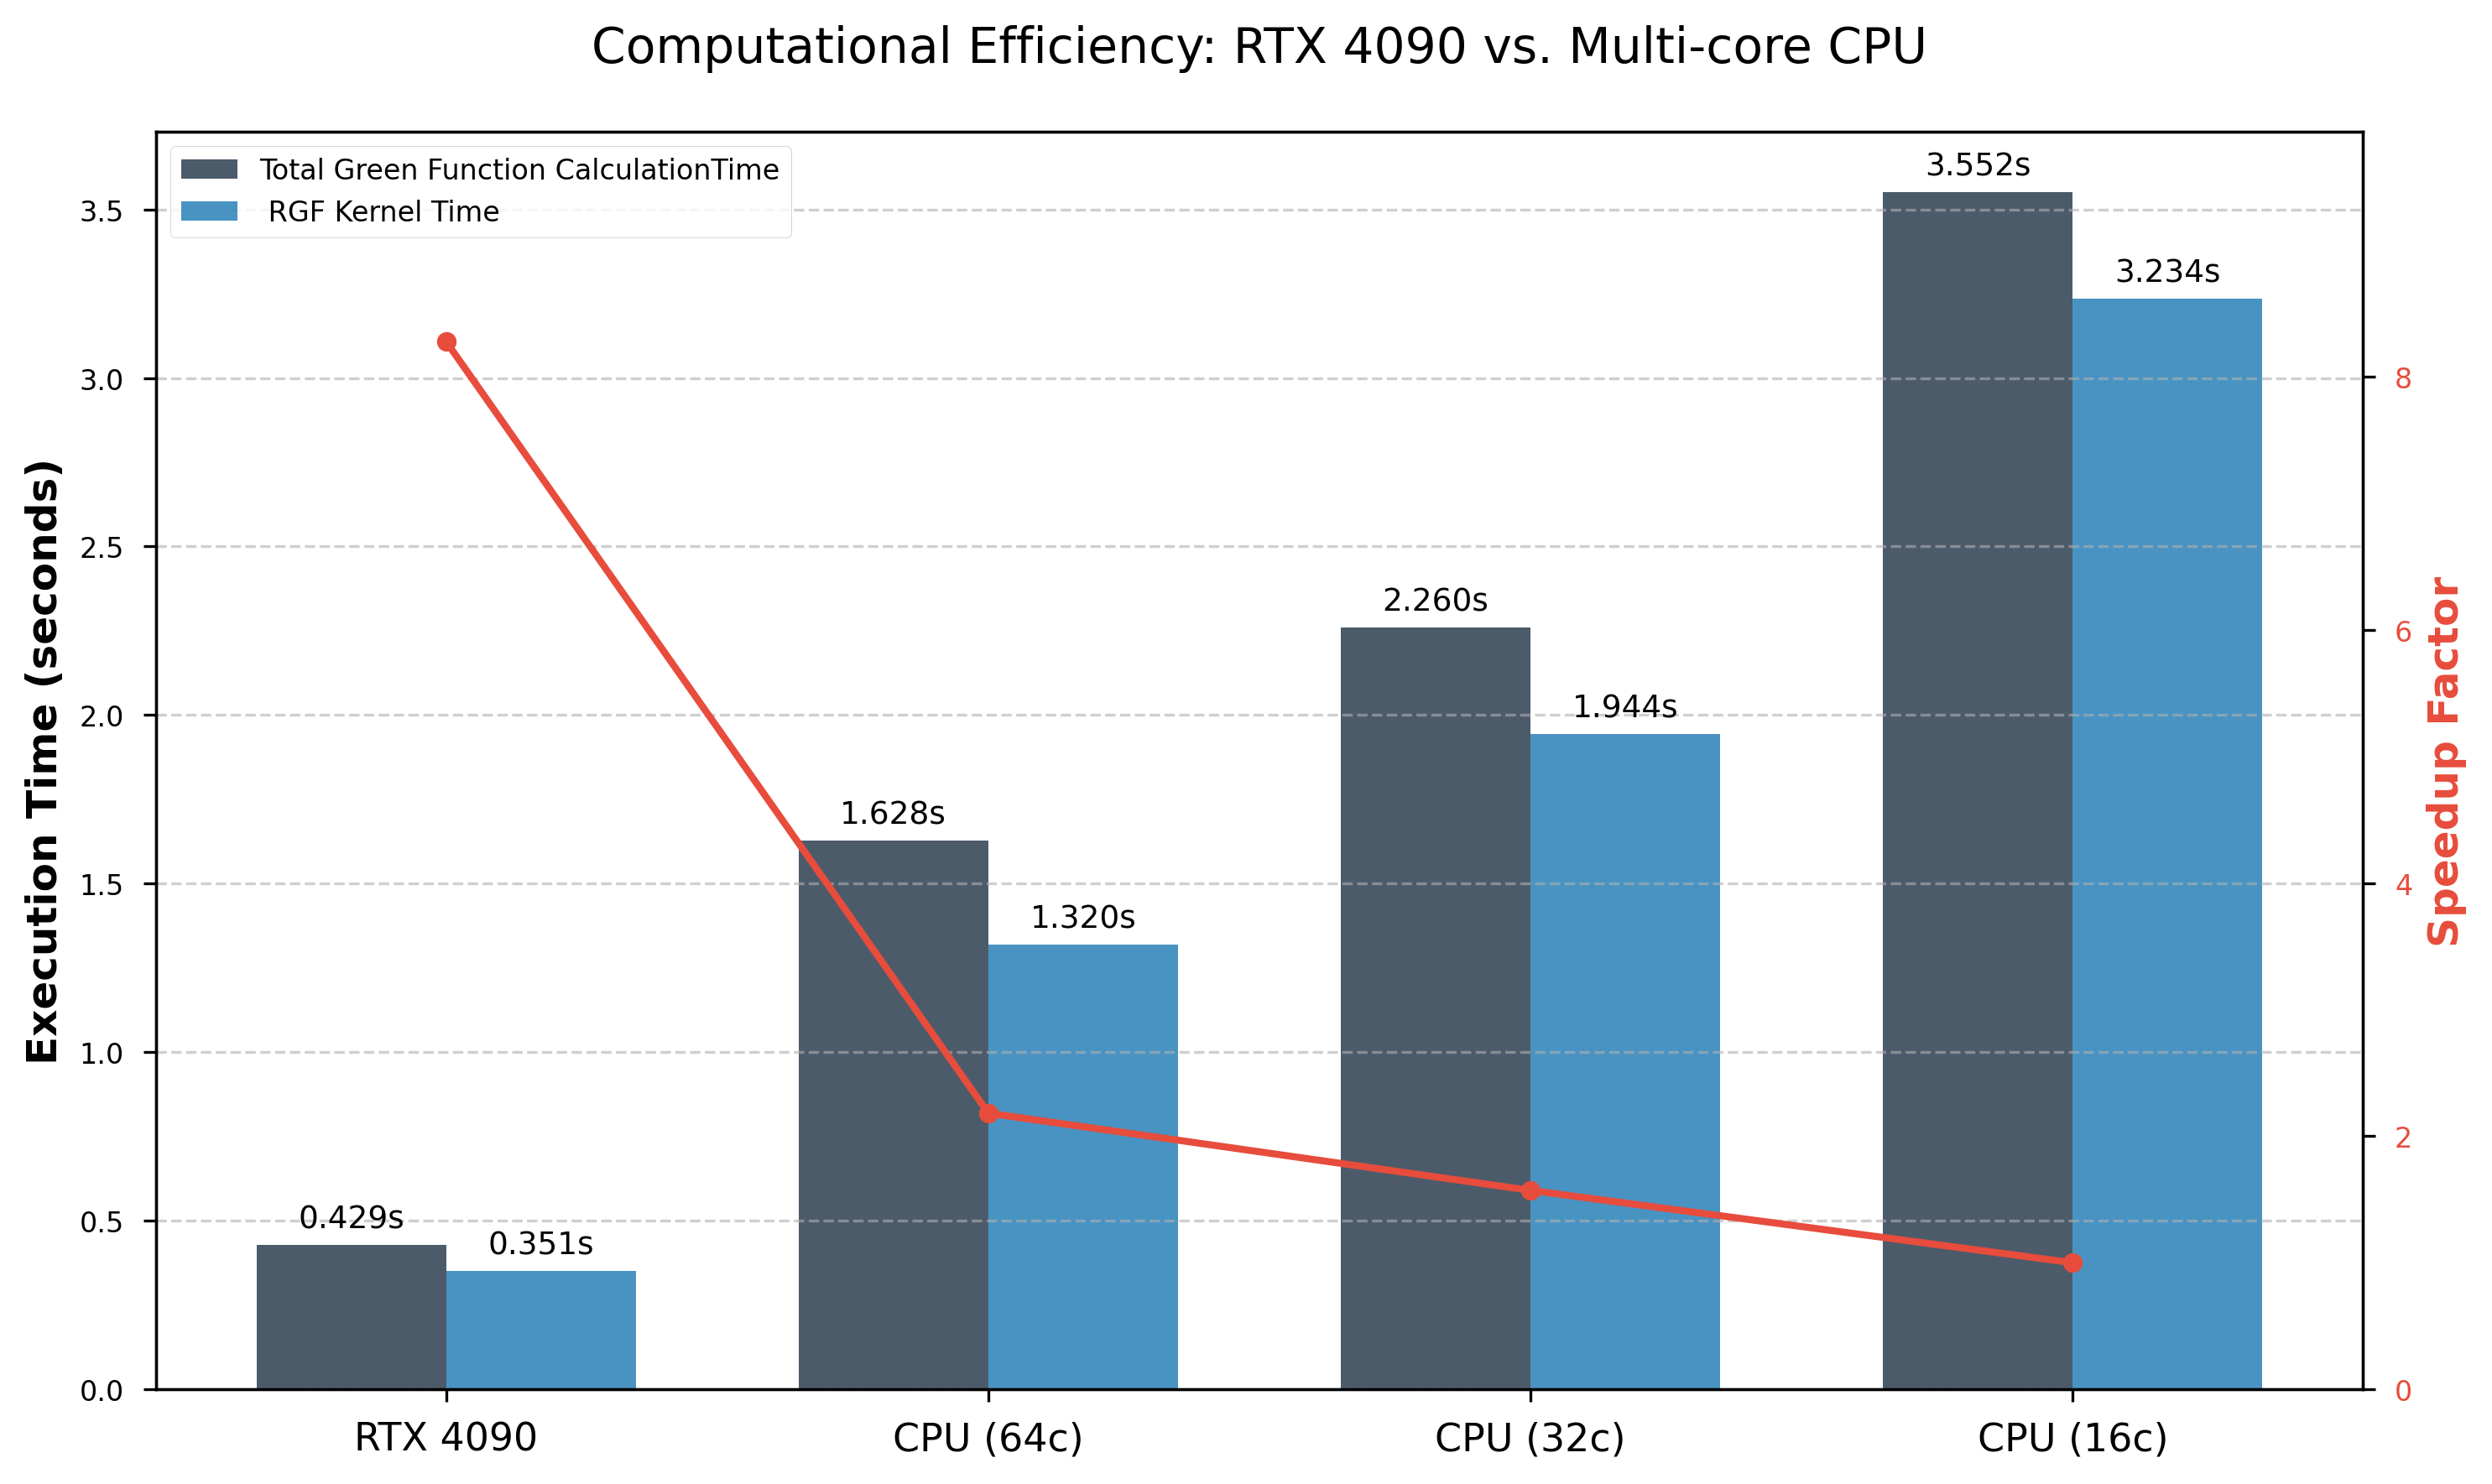

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
labels = ['RTX 4090', 'CPU (64c)', 'CPU (32c)', 'CPU (16c)']
rgf_times = [0.429, 1.628, 2.260, 3.552]
green_times = [0.351, 1.320, 1.944, 3.234]

# 计算加速比 (以 CPU 64核为基准 1x)
base_time = rgf_times[-1]
speedups = [base_time / t for t in rgf_times]

# 设置绘图风格
plt.style.use('seaborn-v0_8-paper')
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

x = np.arange(len(labels))
width = 0.35

# 绘制耗时柱状图
bars1 = ax1.bar(x - width/2, rgf_times, width, label='Total Green Function CalculationTime', color='#2c3e50', alpha=0.85)
bars2 = ax1.bar(x + width/2, green_times, width, label=' RGF Kernel Time', color='#2980b9', alpha=0.85)

# 装饰器
ax1.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Computational Efficiency: RTX 4090 vs. Multi-core CPU', fontsize=14, pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.legend(loc='upper left', frameon=True)

# 添加数值标注
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}s', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

autolabel(bars1)
autolabel(bars2)

# 绘制加速比折线图 (次坐标轴)
ax2 = ax1.twinx()
ax2.plot(x, speedups, color='#e74c3c', marker='o', linewidth=2, label='Speedup (vs 64c)')
ax2.set_ylabel('Speedup Factor', color='#e74c3c', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.set_ylim(0, max(speedups) * 1.2)

# 网格线
ax1.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('gpu_acceleration_benchmark.png')
plt.show()